## 1) Dependances

In [2]:
!pip install -q pandas numpy matplotlib seaborn scikit-learn xgboost tldextract python-whois requests
print('Dependances installees')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 105.9/105.9 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.0/117.0 kB 2.5 MB/s eta 0:00:00
Dependances installees


## 2) Charger le dataset depuis github

In [1]:
import pandas as pd

url = "https://raw.githubusercontent.com/lamisskh/phishing-detection_url/main/dataset_phishing.csv"
df = pd.read_csv(url, sep=None, engine='python')
print(f'Dataset chargé : {df.shape[0]:,} lignes x {df.shape[1]} colonnes')
df.head()

Dataset chargé : 11,430 lignes x 89 colonnes


,url,length_url,length_hostname,ip,nb_dots,nb_hyphens,nb_at,nb_qm,nb_and,nb_or,...,domain_in_title,domain_with_copyright,whois_registered_domain,domain_registration_length,domain_age,web_traffic,dns_record,google_index,page_rank,status
0,http://www.crestonwood.com/router.php,37,19,0,3,0,0,0,0,0,...,0,1,0,45,-1,0,1,1,4,legitimate
1,http://shadetreetechnology.com/V4/validation/a...,77,23,1,1,0,0,0,0,0,...,1,0,0,77,5767,0,0,1,2,phishing
2,https://support-appleld.com.secureupdate.duila...,126,50,1,4,1,0,1,2,0,...,1,0,0,14,4004,5828815,0,1,0,phishing
3,http://rgipt.ac.in,18,11,0,2,0,0,0,0,0,...,1,0,0,62,-1,107721,0,0,3,legitimate
4,http://www.iracing.com/tracks/gateway-motorspo...,55,15,0,2,2,0,0,0,0,...,0,1,0,224,8175,8725,0,0,6,legitimate


##3) Identifier la cible

In [2]:
possible_targets = ['status','label','Label','phishing','Phishing','class','Class','target','Target','is_phishing']
target_col = next((c for c in possible_targets if c in df.columns), df.columns[-1])
print('Colonne cible :', target_col)
print(df[target_col].value_counts(dropna=False))

Colonne cible : status
status
legitimate    5715
phishing      5715
Name: count, dtype: int64


## 4) Audit du dataset EDA — Exploratory Data Analysis

---



In [3]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

print('Shape :', df.shape)
print('Doublons :', df.duplicated().sum())
print('Valeurs manquantes :', int(df.isna().sum().sum()))

resume = pd.DataFrame({
    'colonne': df.columns,
    'type': df.dtypes.astype(str).values,
    'nulls': df.isna().sum().values,
    'uniques': [df[c].nunique() for c in df.columns]
})
display(resume.head(20))


Shape : (11430, 89)
Doublons : 0
Valeurs manquantes : 0


,colonne,type,nulls,uniques
0,url,object,0,11429
1,length_url,int64,0,324
2,length_hostname,int64,0,83
3,ip,int64,0,2
4,nb_dots,int64,0,19
5,nb_hyphens,int64,0,27
6,nb_at,int64,0,5
7,nb_qm,int64,0,4
8,nb_and,int64,0,15
9,nb_or,int64,0,1


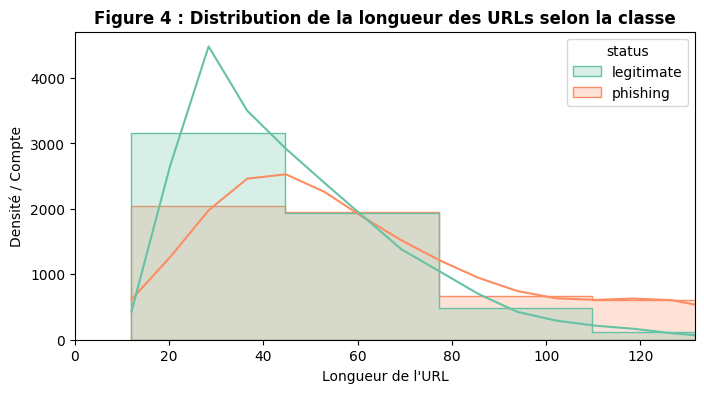

In [4]:
plt.figure(figsize=(8, 4))
sns.histplot(data=df, x='length_url', hue=target_col, kde=True, bins=50, palette='Set2', element='step')
plt.title("Figure 4 : Distribution de la longueur des URLs selon la classe", fontweight='bold')
plt.xlabel("Longueur de l'URL")
plt.ylabel("Densité / Compte")
plt.xlim(0, df['length_url'].quantile(0.95)) # Pour éviter les outliers extrêmes
plt.show()

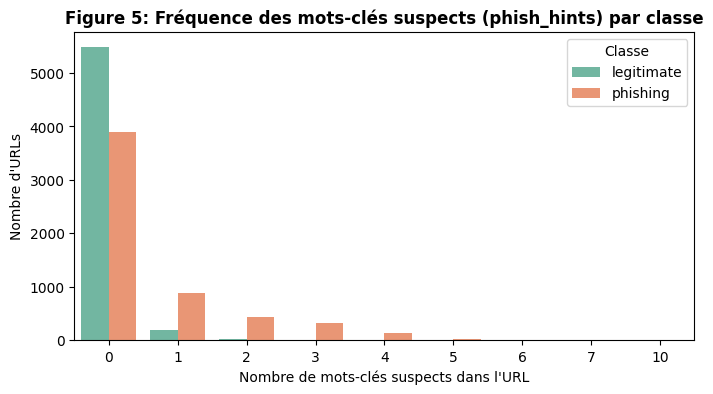

In [5]:
plt.figure(figsize=(8, 4))
sns.countplot(data=df, x='phish_hints', hue=target_col, palette='Set2')
plt.title("Figure 5: Fréquence des mots-clés suspects (phish_hints) par classe", fontweight='bold')
plt.xlabel("Nombre de mots-clés suspects dans l'URL")
plt.ylabel("Nombre d'URLs")
plt.legend(title="Classe")
plt.show()

## 5) Distribution de la cible

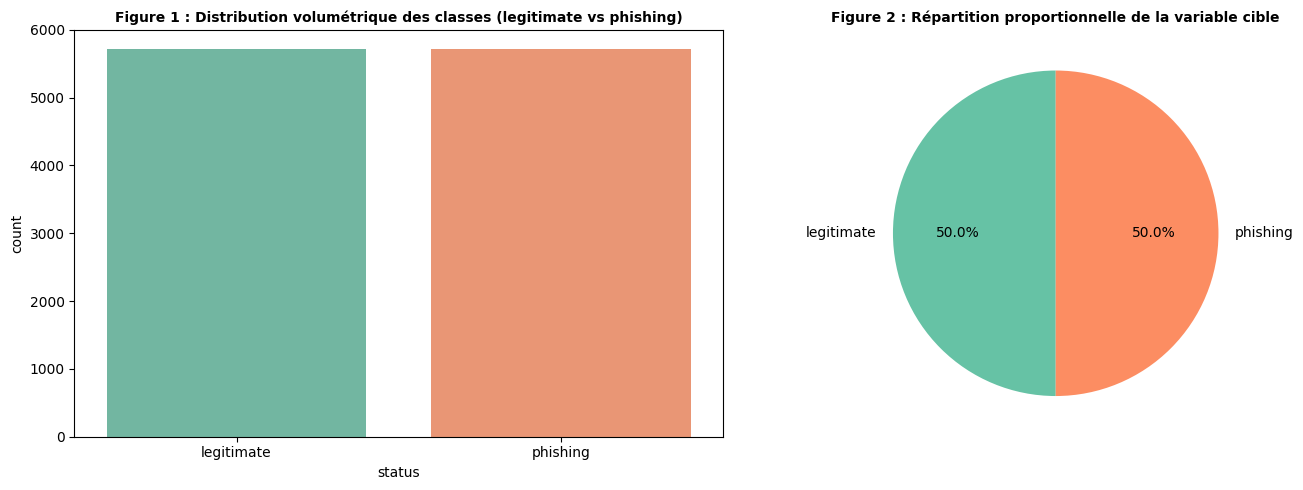

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
counts = df[target_col].value_counts()
colors = sns.color_palette('Set2', len(counts))
sns.countplot(x=df[target_col], palette='Set2', ax=axes[0])
axes[0].set_title("Figure 1 : Distribution volumétrique des classes (legitimate vs phishing)"
, fontsize=10, fontweight='bold')
axes[1].pie(counts, labels=counts.index, autopct='%1.1f%%',
colors=colors, startangle=90)
axes[1].set_title("Figure 2 : Répartition proportionnelle de la variable cible"
, fontsize=10, fontweight='bold')
plt.tight_layout()
plt.show()

Numeric features: 87

Top 9 correlated features:
  google_index: 0.7312
  page_rank: 0.5111
  nb_www: 0.4435
  ratio_digits_url: 0.3564
  domain_in_title: 0.3428
  nb_hyperlinks: 0.3426
  phish_hints: 0.3354
  domain_age: 0.3319
  ip: 0.3217


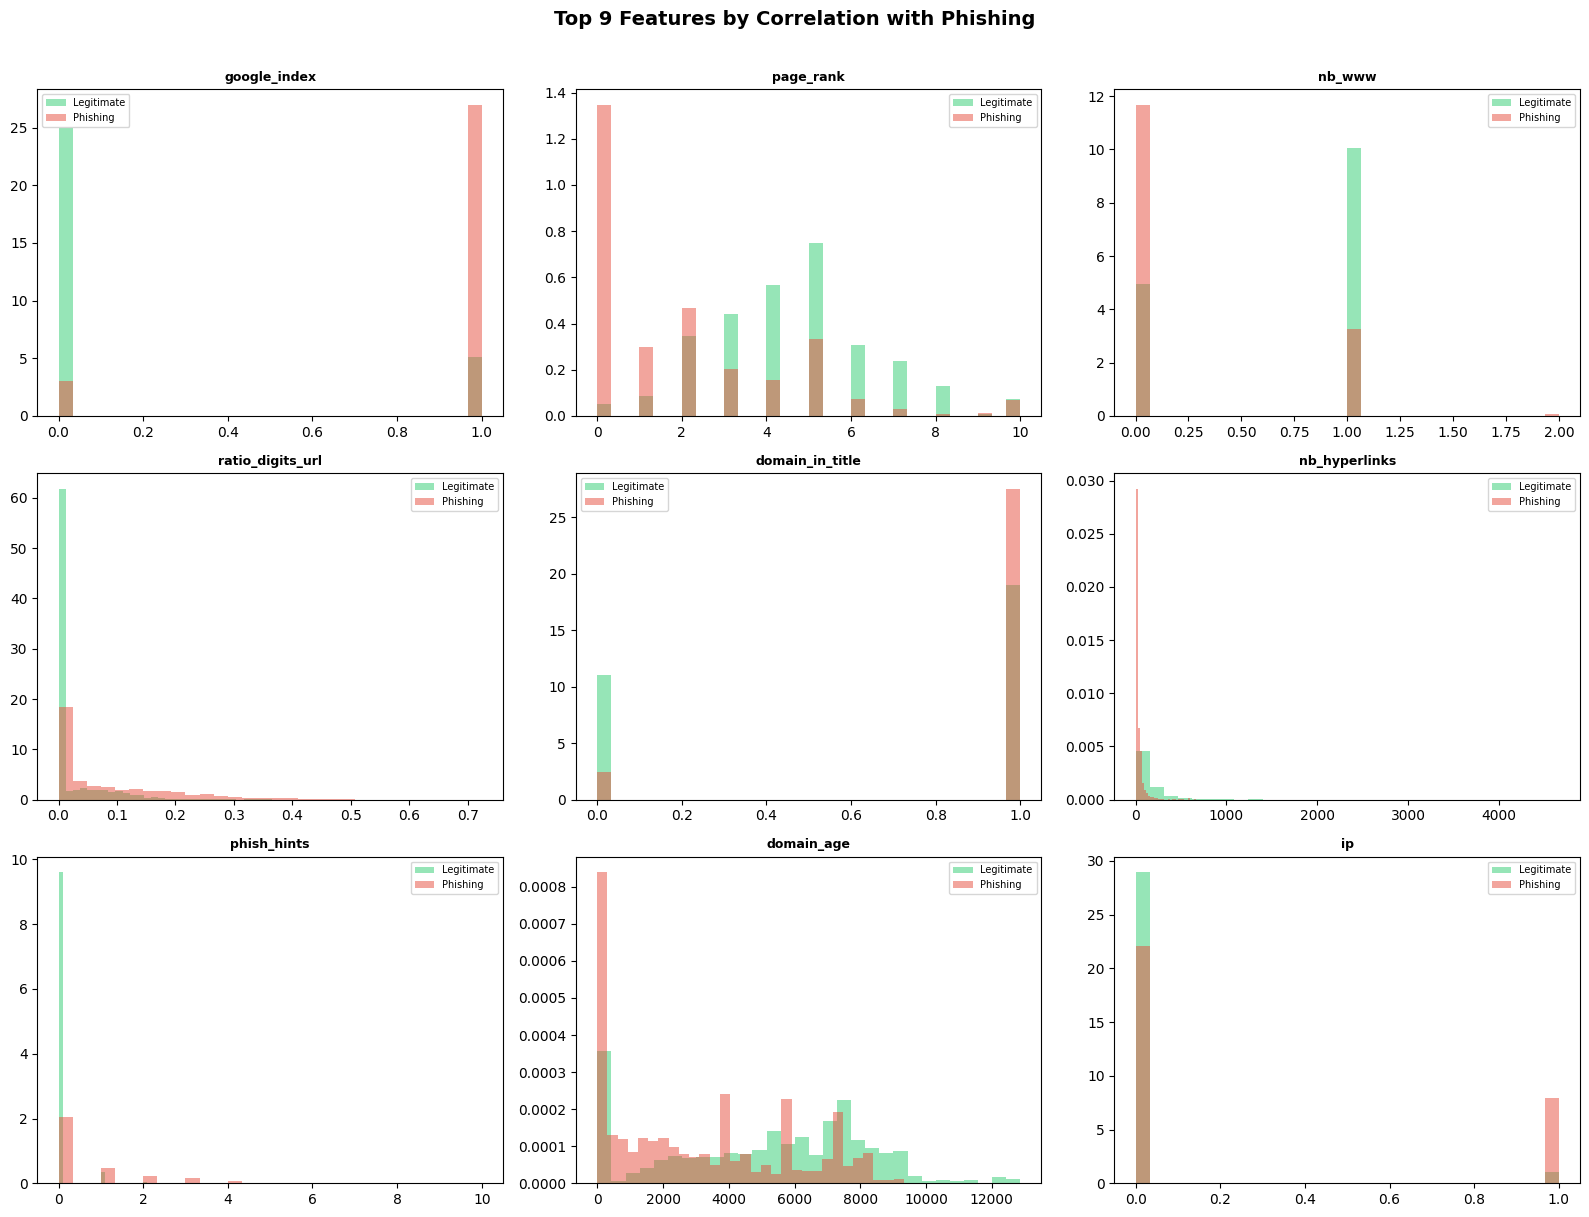

In [10]:
numeric_cols = [c for c in df.select_dtypes(include=[np.number]).columns if c.lower() not in ['id', 'index', target_col]]
print(f"Numeric features: {len(numeric_cols)}")

if len(numeric_cols) > 1:
    target_num = df[target_col].map({'legitimate': 0, 'phishing': 1}) if df[target_col].dtype == 'object' else df[target_col]
    corr_with_target = df[numeric_cols].corrwith(target_num).abs().sort_values(ascending=False)
    top_features = corr_with_target.head(9).index.tolist()
    print("\nTop 9 correlated features:")
    for f in top_features: print(f"  {f}: {corr_with_target[f]:.4f}")

    fig, axes = plt.subplots(3, 3, figsize=(16, 12))
    for ax, col in zip(axes.flatten(), top_features):
        for label, color, name in zip(sorted(df[target_col].unique()), ['#2ecc71', '#e74c3c'], ['Legitimate', 'Phishing']):
            subset = df[df[target_col] == label][col].dropna()
            if len(subset): ax.hist(subset, bins=30, alpha=0.5, label=name, density=True, color=color)
        ax.set_title(col, fontsize=9, fontweight='bold'); ax.legend(fontsize=7)
    plt.suptitle('Top 9 Features by Correlation with Phishing', fontsize=14, fontweight='bold', y=1.01)
    plt.tight_layout(); plt.savefig('feature_distributions.png', dpi=150, bbox_inches='tight'); plt.show()

## 6) Preprocessing



In [6]:
from sklearn.model_selection import train_test_split

df_model = df.copy()

# Suppression doublons
nb_dup = int(df_model.duplicated().sum())
df_model = df_model.drop_duplicates().reset_index(drop=True)
print(f'Doublons supprimes : {nb_dup}')

# Remplissage valeurs manquantes
for col in df_model.select_dtypes(include=[np.number]).columns:
    df_model[col] = df_model[col].fillna(df_model[col].median())
for col in df_model.select_dtypes(include=['object']).columns:
    mode_val = df_model[col].mode(dropna=True)
    df_model[col] = df_model[col].fillna(mode_val.iloc[0] if not mode_val.empty else '')

# Encodage cible
if df_model[target_col].dtype == 'object':
    y_raw = df_model[target_col].astype(str).str.strip().str.lower()
    if set(y_raw.unique()) == {'legitimate', 'phishing'}:
        target_mapping = {'legitimate': 0, 'phishing': 1}
    else:
        labels = sorted(y_raw.unique())
        target_mapping = {l: i for i, l in enumerate(labels)}
    inverse_target_mapping = {v: k for k, v in target_mapping.items()}
    df_model[target_col] = y_raw.map(target_mapping)
else:
    vals = sorted(df_model[target_col].dropna().unique().tolist())
    target_mapping = {int(v): int(v) for v in vals}
    inverse_target_mapping = {int(v): int(v) for v in vals}

# URL a part
url_series = df_model['url'].copy() if 'url' in df_model.columns else pd.Series(['']*len(df_model))

# Features numeriques uniquement
X_full = df_model.drop(columns=[target_col]).copy()
if 'url' in X_full.columns:
    X_full = X_full.drop(columns=['url'])
X_full = X_full.select_dtypes(include=[np.number]).copy()
y_full = df_model[target_col].astype(int).copy()

# Colonnes constantes
constant_cols = [c for c in X_full.columns if X_full[c].nunique(dropna=False) <= 1]
X_full = X_full.drop(columns=constant_cols)

# Colonnes tres correlees (>= 0.98)
corr_mat = X_full.corr().abs()
upper = corr_mat.where(np.triu(np.ones(corr_mat.shape), k=1).astype(bool))
high_corr_cols = [c for c in upper.columns if any(upper[c] > 0.98)]
X_full = X_full.drop(columns=high_corr_cols)

feature_columns = X_full.columns.tolist()
feature_medians = X_full.median().to_dict()

print(f'Colonnes constantes supprimees   : {len(constant_cols)}')
print(f'Colonnes tres correlees supprimees : {len(high_corr_cols)}')
print(f'Features finales : {len(feature_columns)}')

# Split 70 / 20 / 10
X_temp, X_test, y_temp, y_test = train_test_split(X_full, y_full, test_size=0.10, random_state=42, stratify=y_full)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=2/9, random_state=42, stratify=y_temp)
print(f'Train : {X_train.shape[0]}  |  Val : {X_val.shape[0]}  |  Test : {X_test.shape[0]}')

Doublons supprimes : 0
Colonnes constantes supprimees   : 6
Colonnes tres correlees supprimees : 0
Features finales : 81
Train : 8001  |  Val : 2286  |  Test : 1143


## 7) Correlations avec la cible

Top 15 features corrélées à la cible :
google_index           0.731171
page_rank              0.511137
nb_www                 0.443468
ratio_digits_url       0.356395
domain_in_title        0.342807
nb_hyperlinks          0.342628
phish_hints            0.335393
domain_age             0.331889
ip                     0.321698
nb_qm                  0.294319
length_url             0.248580
ratio_intHyperlinks    0.243982
nb_slash               0.242270
length_hostname        0.238322
nb_eq                  0.233386
Name: status, dtype: float64


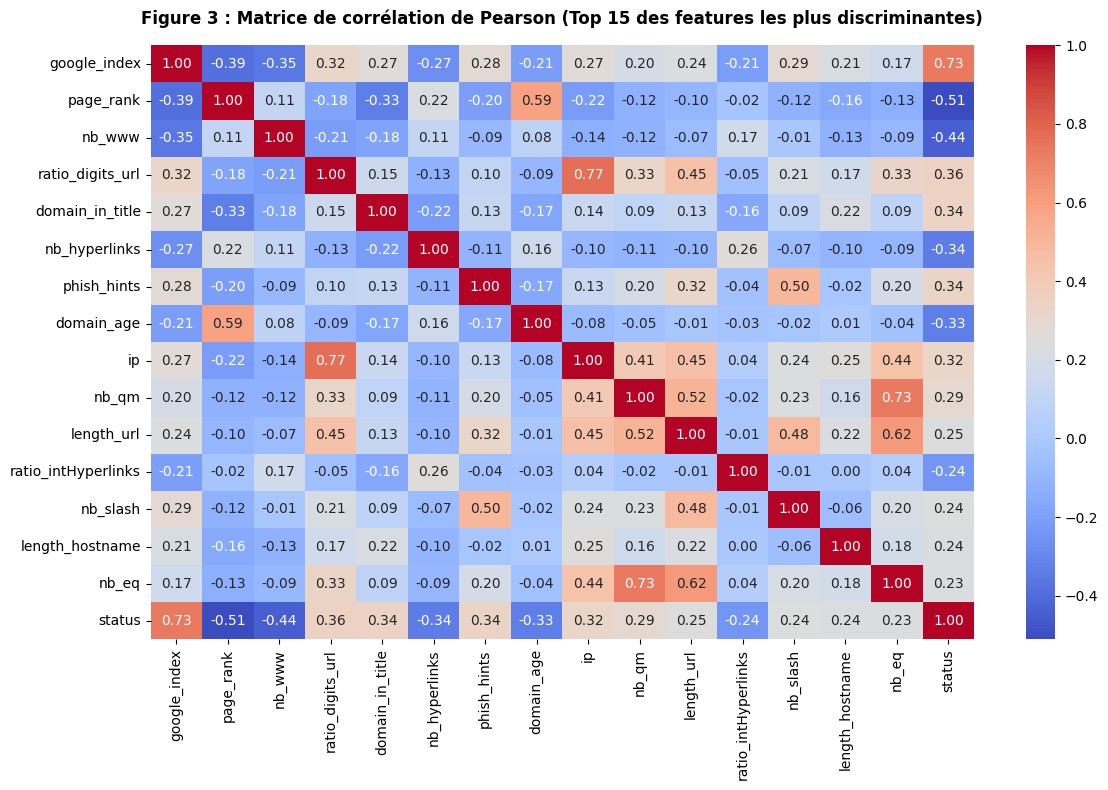

In [12]:
# 1. Préparation des données de corrélation
corr_df = X_full.copy()
corr_df[target_col] = y_full.values
# 2. Calcul des corrélations absolues avec la cible
corr_vals = corr_df.corr(numeric_only=True)[target_col].drop(target_col).abs().sort_values(ascending=False)
print('Top 15 features corrélées à la cible :')
print(corr_vals.head(15))
# 3. Extraction des 15 meilleures caractéristiques
top_feats = corr_vals.head(15).index.tolist()
# 4. Génération de la Figure 3 (Heatmap)
plt.figure(figsize=(12, 8))
sns.heatmap(corr_df[top_feats + [target_col]].corr(), annot=True, cmap='coolwarm', fmt='.2f')
# Titre officiel numéroté pour respecter le barème du professeur
plt.title("Figure 3 : Matrice de corrélation de Pearson (Top 15 des features les plus discriminantes)"
, fontsize=12, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

### 8) Comparaison de modeles



In [13]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC  # ✅ SVM à la place de LightGBM
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, roc_auc_score
import xgboost as xgb

models = {
    'Logistic Regression': LogisticRegression(max_iter=2000, random_state=42),
    'RandomForest': RandomForestClassifier(
        n_estimators=300, random_state=42, n_jobs=-1,
        class_weight='balanced_subsample'
    ),
    'XGBoost': xgb.XGBClassifier(
        n_estimators=300, max_depth=6, learning_rate=0.05,
        subsample=0.9, colsample_bytree=0.9,
        reg_lambda=1.0,
        random_state=42, eval_metric='logloss'
    ),
    'SVM': SVC(kernel='rbf', probability=True, random_state=42)  # ✅ remplace LightGBM
}

rows, trained_models = [], {}
for name, model in models.items():
    model.fit(X_train, y_train)
    val_proba = model.predict_proba(X_val)[:, 1]
    val_pred  = (val_proba >= 0.5).astype(int)
    rows.append({
        'Model': name,
        'Accuracy':  accuracy_score(y_val, val_pred),
        'Precision': precision_score(y_val, val_pred),
        'Recall':    recall_score(y_val, val_pred),
        'F1':        f1_score(y_val, val_pred),
        'ROC_AUC':   roc_auc_score(y_val, val_proba)
    })
    trained_models[name] = model

results_df = pd.DataFrame(rows).sort_values(['F1','ROC_AUC','Accuracy'], ascending=False).reset_index(drop=True)
display(results_df)

,Model,Accuracy,Precision,Recall,F1,ROC_AUC
0,XGBoost,0.968066,0.970123,0.965879,0.967996,0.994480
1,RandomForest,0.964567,0.969081,0.959755,0.964396,0.993276
2,Logistic Regression,0.809711,0.807826,0.812773,0.810292,0.888542
3,SVM,0.616360,0.579450,0.848644,0.688676,0.762048


## 9) Visualiser la comparaison

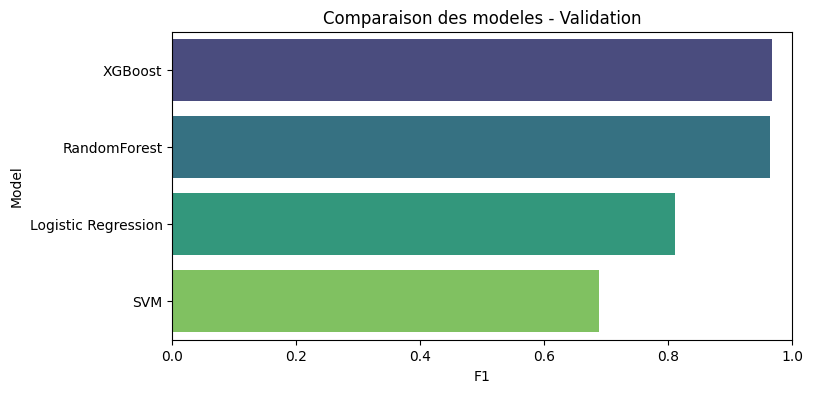

Meilleur modele : XGBoost


In [15]:
plt.figure(figsize=(8, 4))
sns.barplot(data=results_df, x='F1', y='Model', palette='viridis')
plt.title('Comparaison des modeles - Validation')
plt.xlim(0, 1)
plt.show()

best_model_name = results_df.iloc[0]['Model']
best_model      = trained_models[best_model_name]
print('Meilleur modele :', best_model_name)

## 10) Chercher le meilleur seuil sur la validation



,threshold,f1,precision,recall,accuracy
45,0.55,0.968338,0.973475,0.963255,0.968504
33,0.43,0.968080,0.967657,0.968504,0.968066
34,0.44,0.968053,0.968476,0.967629,0.968066
35,0.45,0.968053,0.968476,0.967629,0.968066
36,0.46,0.968053,0.968476,0.967629,0.968066
39,0.49,0.967996,0.970123,0.965879,0.968066
40,0.50,0.967996,0.970123,0.965879,0.968066
42,0.52,0.967940,0.971781,0.964129,0.968066
43,0.53,0.967912,0.972615,0.963255,0.968066
44,0.54,0.967912,0.972615,0.963255,0.968066


Seuil optimal : 0.55


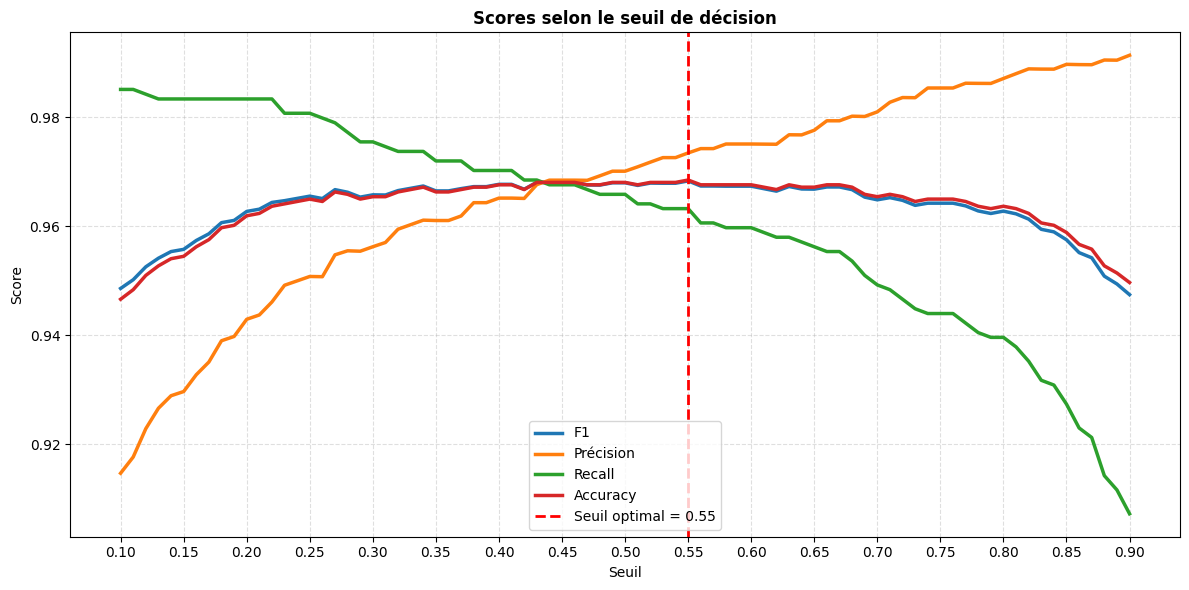

In [17]:
val_proba = best_model.predict_proba(X_val)[:, 1]
threshold_rows = []

for t in np.round(np.arange(0.10, 0.91, 0.01), 2):
    pred_t = (val_proba >= t).astype(int)
    threshold_rows.append({
        'threshold': t,
        'f1':        f1_score(y_val, pred_t),
        'precision': precision_score(y_val, pred_t),
        'recall':    recall_score(y_val, pred_t),
        'accuracy':  accuracy_score(y_val, pred_t)
    })

threshold_df   = pd.DataFrame(threshold_rows).sort_values(['f1','accuracy','precision'], ascending=False)
best_threshold = float(threshold_df.iloc[0]['threshold'])
display(threshold_df.head(10))
print('Seuil optimal :', best_threshold)

tdf = threshold_df.sort_values('threshold')
plt.figure(figsize=(12, 6))
for col, label in [('f1','F1'), ('precision','Précision'), ('recall','Recall'), ('accuracy','Accuracy')]:
    plt.plot(tdf['threshold'], tdf[col], linewidth=2.5, label=label)
plt.axvline(best_threshold, color='red', linewidth=2, linestyle='--', label=f'Seuil optimal = {best_threshold}')
plt.annotate(f'  Seuil = {best_threshold}', xy=(best_threshold, 0.5), fontsize=11, color='red', fontweight='bold')
plt.xlabel('Seuil'); plt.ylabel('Score'); plt.title('Scores selon le seuil de décision', fontweight='bold')
plt.legend(); plt.grid(True, alpha=0.4, linestyle='--'); plt.xticks(np.arange(0.1, 0.95, 0.05))
plt.tight_layout(); plt.show()

## 11) Entrainement final sur train + validation, puis test non vu

              precision    recall  f1-score   support

  legitimate       0.97      0.96      0.97       572
    phishing       0.96      0.97      0.97       571

    accuracy                           0.97      1143
   macro avg       0.97      0.97      0.97      1143
weighted avg       0.97      0.97      0.97      1143



,best_model,threshold,accuracy,precision,recall,f1,roc_auc
0,XGBoost,0.55,0.965879,0.960208,0.971979,0.966057,0.99372


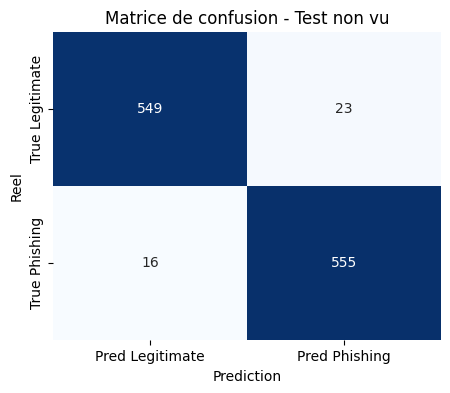

In [13]:
from sklearn.metrics import classification_report, confusion_matrix

X_train_final = pd.concat([X_train, X_val], axis=0)
y_train_final = pd.concat([y_train, y_val], axis=0)

final_model = models[best_model_name]
final_model.fit(X_train_final, y_train_final)

test_proba = final_model.predict_proba(X_test)[:, 1]
test_pred  = (test_proba >= best_threshold).astype(int)

print(classification_report(y_test, test_pred, target_names=['legitimate', 'phishing']))

metrics_test = {
    'best_model': best_model_name, 'threshold': best_threshold,
    'accuracy':  accuracy_score(y_test, test_pred),
    'precision': precision_score(y_test, test_pred),
    'recall':    recall_score(y_test, test_pred),
    'f1':        f1_score(y_test, test_pred),
    'roc_auc':   roc_auc_score(y_test, test_proba)
}
display(pd.DataFrame([metrics_test]))

cm = confusion_matrix(y_test, test_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Pred Legitimate', 'Pred Phishing'],
            yticklabels=['True Legitimate', 'True Phishing'])
plt.title('Matrice de confusion - Test non vu')
plt.xlabel('Prediction'); plt.ylabel('Reel')
plt.show()

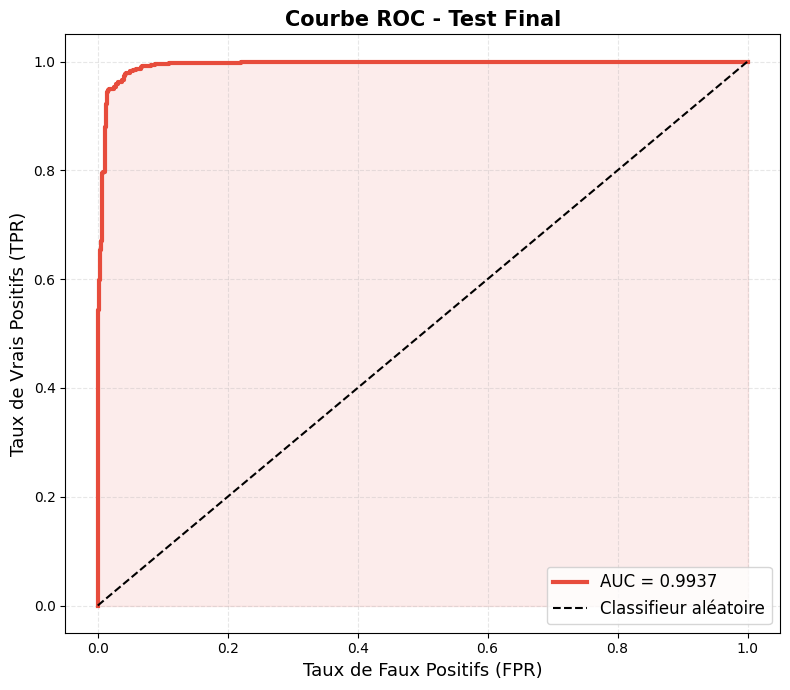

In [14]:
from sklearn.metrics import roc_curve, auc

fpr, tpr, _ = roc_curve(y_test, test_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 7))
plt.plot(fpr, tpr, color='#e74c3c', linewidth=3, label=f'AUC = {roc_auc:.4f}')
plt.fill_between(fpr, tpr, alpha=0.1, color='#e74c3c')
plt.plot([0,1],[0,1], 'k--', linewidth=1.5, label='Classifieur aléatoire')
plt.xlabel('Taux de Faux Positifs (FPR)', fontsize=13)
plt.ylabel('Taux de Vrais Positifs (TPR)', fontsize=13)
plt.title('Courbe ROC - Test Final', fontsize=15, fontweight='bold')
plt.legend(fontsize=12, loc='lower right')
plt.grid(True, alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show()

## 12) Importance des variables

,feature,importance
79,google_index,0.504581
80,page_rank,0.036864
19,nb_www,0.032729
55,nb_hyperlinks,0.027639
6,nb_qm,0.025407
52,brand_in_path,0.023318
25,ratio_digits_host,0.020455
49,phish_hints,0.016865
22,http_in_path,0.015068
14,nb_colon,0.014729


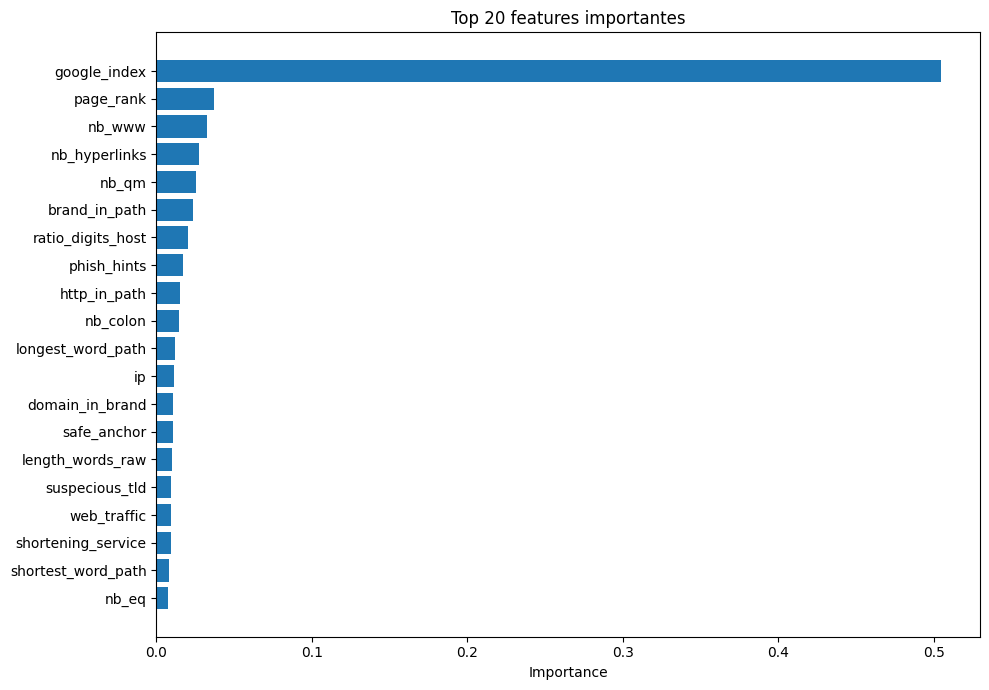

In [15]:
if hasattr(final_model, 'feature_importances_'):
    importance_df = pd.DataFrame({
        'feature':    feature_columns,
        'importance': final_model.feature_importances_
    }).sort_values('importance', ascending=False)
    display(importance_df.head(20))

    plt.figure(figsize=(10, 7))
    top20 = importance_df.head(20).sort_values('importance')
    plt.barh(top20['feature'], top20['importance'])
    plt.title('Top 20 features importantes')
    plt.xlabel('Importance')
    plt.tight_layout()
    plt.show()
else:
    print('Le modele choisi ne fournit pas feature_importances_.')

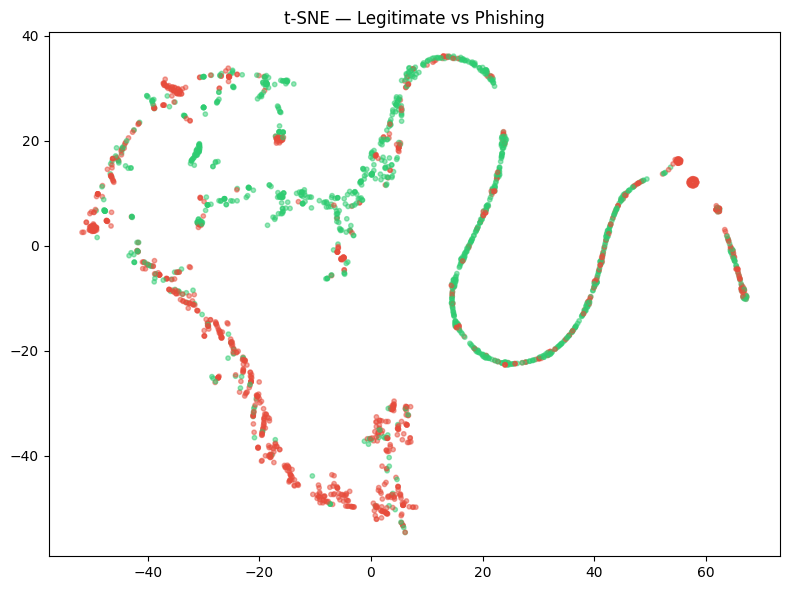

In [36]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
X_tsne = tsne.fit_transform(X_full.sample(2000, random_state=42))
y_tsne = y_full.loc[X_full.sample(2000, random_state=42).index]
plt.figure(figsize=(8,6))
colors = ['#2ecc71' if l==0 else '#e74c3c' for l in y_tsne]
plt.scatter(X_tsne[:,0], X_tsne[:,1], c=colors, alpha=0.5, s=10)
plt.title('t-SNE — Legitimate vs Phishing')
plt.tight_layout()
plt.show()

## 13) Sauvegarde des artefacts

In [16]:
import joblib

TRUSTED_DOMAINS = {
    'google.com','youtube.com','gmail.com','facebook.com','instagram.com',
    'whatsapp.com','microsoft.com','live.com','outlook.com','office.com',
    'github.com','apple.com','amazon.com','paypal.com','linkedin.com',
    'dropbox.com','adobe.com','openai.com','wikipedia.org','netflix.com',
    'twitter.com','reddit.com','booking.com'
}

artifacts = {
    'model':                  final_model,
    'best_model_name':        best_model_name,
    'feature_columns':        feature_columns,
    'feature_medians':        feature_medians,
    'threshold':              best_threshold,
    'target_mapping':         target_mapping,
    'inverse_target_mapping': inverse_target_mapping,
    'trusted_domains':        sorted(TRUSTED_DOMAINS),
    'constant_cols_removed':  constant_cols,
    'high_corr_cols_removed': high_corr_cols,
    'test_metrics':           metrics_test
}

joblib.dump(artifacts, 'phishing_detector_artifacts.joblib')
if 'importance_df' in globals():
    importance_df.to_csv('feature_importance_final.csv', index=False)

print('Artefact sauvegarde : phishing_detector_artifacts.joblib')

Artefact sauvegarde : phishing_detector_artifacts.joblib


## 14) Fonctions de prediction



In [17]:
import re, socket, urllib.parse, requests, tldextract
from datetime import datetime

artifacts       = joblib.load('phishing_detector_artifacts.joblib')
final_model     = artifacts['model']
feature_columns = artifacts['feature_columns']
feature_medians = artifacts['feature_medians']
best_threshold  = float(artifacts['threshold'])
TRUSTED_DOMAINS = set(artifacts['trusted_domains'])

HTML_FEATURES = [
    'nb_hyperlinks','ratio_intHyperlinks','ratio_extHyperlinks','ratio_nullHyperlinks',
    'nb_extCSS','ratio_intRedirection','ratio_extRedirection','ratio_intErrors',
    'ratio_extErrors','login_form','external_favicon','links_in_tags','submit_email',
    'ratio_intMedia','ratio_extMedia','sfh','iframe','popup_window','safe_anchor',
    'onmouseover','right_clic','empty_title','domain_in_title','domain_with_copyright'
]

def normalize_url(url):
    url = url.strip()
    return url if re.match(r'^https?://', url, re.I) else 'http://' + url

def get_registered_domain(url):
    ext = tldextract.extract(url)
    rd  = getattr(ext, 'registered_domain', '')
    return rd.lower() if rd else '.'.join(p for p in [ext.domain, ext.suffix] if p).lower()

def get_domain_info(url):
    info = {'domain_age': -1, 'domain_registration_length': -1, 'whois_registered_domain': 0, 'dns_record': 0}
    domain = get_registered_domain(url)
    try:
        socket.gethostbyname(domain)
        info['dns_record'] = 1
    except: pass
    try:
        import whois
        w = whois.whois(domain)
        creation = w.creation_date[0] if isinstance(w.creation_date, list) else w.creation_date
        expiry   = w.expiration_date[0] if isinstance(w.expiration_date, list) else w.expiration_date
        if creation:
            info['domain_age'] = max((datetime.now() - creation).days, 0)
            info['whois_registered_domain'] = 1
        if creation and expiry:
            info['domain_registration_length'] = max((expiry - creation).days, 0)
    except: pass
    return info

def fetch_page_features(url):
    feats = {h: 0 for h in HTML_FEATURES}
    try:
        resp  = requests.get(url, timeout=8, headers={'User-Agent': 'Mozilla/5.0'}, allow_redirects=True)
        html  = resp.text.lower()
        dom   = urllib.parse.urlparse(url).netloc.lower()
        links = re.findall(r"href=['\"]([^'\"]+)['\"]", html)
        nb    = len(links)
        feats['nb_hyperlinks'] = nb
        if nb:
            feats['ratio_intHyperlinks']  = len([l for l in links if dom in l or l.startswith('/')]) / nb
            feats['ratio_extHyperlinks']  = len([l for l in links if dom not in l and l.startswith('http')]) / nb
            feats['ratio_nullHyperlinks'] = len([l for l in links if l in ['#','','javascript:void(0)']]) / nb
        feats['login_form']   = 1 if re.search(r'<form[^>]*>.*?(password|login|signin)', html, re.DOTALL) else 0
        feats['submit_email'] = 1 if re.search(r"action=['\"]mailto:", html) else 0
        feats['sfh']          = 1 if re.search(r"action=['\"]about:blank", html) else 0
        feats['iframe']       = 1 if '<iframe' in html else 0
        feats['popup_window'] = 1 if 'window.open' in html else 0
        feats['onmouseover']  = 1 if 'onmouseover' in html else 0
        feats['right_clic']   = 1 if 'event.button==2' in html else 0
        m = re.search(r'<title>(.*?)</title>', html)
        title = m.group(1) if m else ''
        feats['empty_title']     = 1 if not title.strip() else 0
        feats['domain_in_title'] = 1 if dom.split('.')[0] in title else 0
        fav = re.search(r"rel=['\"].*?icon['\"][^>]*href=['\"]([^'\"]+)", html)
        if fav: feats['external_favicon'] = 1 if dom not in fav.group(1) else 0
        ext_css = re.findall(r"<link[^>]+href=['\"]https?://([^'\"]+\.css)['\"]", html)
        feats['nb_extCSS'] = sum(1 for c in ext_css if dom not in c)
        feats['domain_with_copyright'] = 1 if re.search(r'copyright', html) and dom.split('.')[0] in html else 0
    except: pass
    return feats

def extract_features(url, fetch_page=False):
    url    = normalize_url(url)
    parsed = urllib.parse.urlparse(url)
    host   = parsed.netloc.lower()
    path   = parsed.path or ''
    wu = re.findall(r'\w+', url)
    wh = [w for w in host.split('.') if w]
    wp = re.findall(r'\w+', path)
    f = {
        'length_url': len(url), 'length_hostname': len(host),
        'ip': 1 if re.match(r'^\d{1,3}(\.\d{1,3}){3}$', host) else 0,
        'nb_dots': url.count('.'),       'nb_hyphens': url.count('-'),
        'nb_at': url.count('@'),         'nb_qm': url.count('?'),
        'nb_and': url.count('&'),        'nb_or': url.count('|'),
        'nb_eq': url.count('='),         'nb_underscore': url.count('_'),
        'nb_tilde': url.count('~'),      'nb_percent': url.count('%'),
        'nb_slash': url.count('/'),      'nb_star': url.count('*'),
        'nb_colon': url.count(':'),      'nb_comma': url.count(','),
        'nb_semicolumn': url.count(';'), 'nb_dollar': url.count('$'),
        'nb_space': url.count(' '),      'nb_www': url.lower().count('www'),
        'nb_com': url.lower().count('.com'), 'nb_dslash': url.count('//'),
        'http_in_path': 1 if 'http' in path.lower() else 0,
        'https_token': 1 if parsed.scheme == 'https' else 0,
        'ratio_digits_url':  sum(c.isdigit() for c in url)  / max(len(url),  1),
        'ratio_digits_host': sum(c.isdigit() for c in host) / max(len(host), 1),
        'punycode': 1 if 'xn--' in url.lower() else 0,
        'port': 1 if parsed.port else 0,
        'tld_in_path':      1 if any(t in path.lower() for t in ['.com','.net','.org']) else 0,
        'tld_in_subdomain': 1 if any(t in host.split('.')[0] for t in ['com','net','org']) else 0,
        'abnormal_subdomain': 1 if re.match(r'^(w[0-9]+|web\d*)', host) else 0,
        'nb_subdomains': max(host.count('.') - 1, 0),
        'prefix_suffix': 1 if '-' in host else 0,
        'shortening_service': 1 if any(s in host for s in ['bit.ly','tinyurl','goo.gl','t.co']) else 0,
        'path_extension': 1 if re.search(r'\.(exe|php|html|zip|rar|js)$', path.lower()) else 0,
        'nb_redirection': max(url.count('//') - 1, 0), 'nb_external_redirection': 0,
        'length_words_raw':   len(wu),
        'char_repeat':        max([url.count(c) for c in set(url)]) if url else 0,
        'shortest_words_raw': min((len(w) for w in wu),  default=0),
        'shortest_word_host': min((len(w) for w in wh), default=0),
        'shortest_word_path': min((len(w) for w in wp), default=0),
        'longest_words_raw':  max((len(w) for w in wu),  default=0),
        'longest_word_host':  max((len(w) for w in wh), default=0),
        'longest_word_path':  max((len(w) for w in wp), default=0),
        'avg_words_raw':  np.mean([len(w) for w in wu]) if wu else 0,
        'avg_word_host':  np.mean([len(w) for w in wh]) if wh else 0,
        'avg_word_path':  np.mean([len(w) for w in wp]) if wp else 0,
        'phish_hints': sum(url.lower().count(w) for w in [
            'secure','account','update','login','verify','confirm','banking','paypal','password']),
        'domain_in_brand': 0, 'brand_in_subdomain': 0, 'brand_in_path': 0,
        'suspecious_tld': 1 if any(host.endswith(t) for t in [
            '.tk','.ml','.ga','.cf','.gq','.xyz','.top','.club']) else 0,
        'statistical_report': 0,
        'web_traffic': -1, 'google_index': -1, 'page_rank': -1,
    }
    if fetch_page:
        f.update(fetch_page_features(url))
    else:
        for h in HTML_FEATURES:
            f[h] = feature_medians.get(h, 0)
    f.update(get_domain_info(url))
    return f

def trusted_domain_override(url, features):
    rd = get_registered_domain(url)
    red_flags = [
        features.get('ip',                 0) == 1,
        features.get('punycode',           0) == 1,
        features.get('shortening_service', 0) == 1,
        features.get('suspecious_tld',     0) == 1,
        features.get('nb_at',              0) > 0,
        features.get('https_token',        0) == 0,
        features.get('phish_hints',        0) > 1,
    ]
    allow = rd in TRUSTED_DOMAINS and features.get('dns_record', 0) == 1 and not any(red_flags)
    return allow, rd

def predict_url(url, fetch_page=False, verbose=True):
    url      = normalize_url(url)
    features = extract_features(url, fetch_page=fetch_page)
    row = pd.DataFrame([features])
    for col in feature_columns:
        if col not in row.columns:
            row[col] = feature_medians.get(col, 0)
        val = row.at[0, col]
        if pd.isna(val) or val == -1:
            row.at[0, col] = feature_medians.get(col, 0)
    row = row[feature_columns]
    proba        = float(final_model.predict_proba(row)[0, 1])
    model_pred   = int(proba >= best_threshold)
    override, rd = trusted_domain_override(url, features)
    final_pred   = 0 if override else model_pred
    label        = 'LEGITIMATE' if final_pred == 0 else 'PHISHING'
    confidence   = max(1 - proba, 0.5) if final_pred == 0 else max(proba, 0.5)
    if verbose:
        print('=' * 65)
        print(f'URL      : {url}')
        print(f'Domaine  : {rd or "N/A"}')
        print(f'Proba    : {proba:.4f}  |  Seuil : {best_threshold}')
        if override: print('Override : domaine de confiance')
        print(f'Resultat : {label}  ({confidence*100:.1f}%)')
        print('=' * 65)
    return {
        'url': url, 'registered_domain': rd,
        'model_phishing_probability': round(proba, 4),
        'prediction': int(final_pred),
        'label': 'legitimate' if final_pred == 0 else 'phishing',
        'override_legitimate': bool(override)
    }

print('Fonctions de prediction pretes')

Fonctions de prediction pretes


## 15) Test final

In [18]:
test_urls = [
    'https://mail.google.com/mail/u/0/?pli=1#inbox',
    'http://secure-paypal-login.tk/verify?account=true',
    'https://www.youtube.com/',
    'http://free-iphone-winner.xyz/claim',
    'https://classroom.google.com/h',
    'https://www.facebook.com/?locale=fr_FR',
    'https://www.asterisk.org/',
    'https://www.instagram.com/?hl=fr',
    'https://www.netflix.com/browse',
    'https://whatsapp-security-check.example.com',
    'https://www.booking.com',
    'https://www.wataan.com/',
    'http://steam-community-login.example.org',
    'https://www.amazon.com',
    'https://www.apple.com',
    'http://amaz0n-verification.org',
    'https://www.dropbox.com'
]

pred_rows = [predict_url(url, fetch_page=False) for url in test_urls]
pred_df   = pd.DataFrame(pred_rows)
display(pred_df[['url','registered_domain','model_phishing_probability','prediction','label','override_legitimate']])

URL      : https://mail.google.com/mail/u/0/?pli=1#inbox
Domaine  : google.com
Proba    : 0.8568  |  Seuil : 0.55
Override : domaine de confiance
Resultat : LEGITIMATE  (50.0%)


ERROR:whois.whois:Error trying to connect to socket: closing socket - timed out


URL      : http://secure-paypal-login.tk/verify?account=true
Domaine  : secure-paypal-login.tk
Proba    : 0.9910  |  Seuil : 0.55
Resultat : PHISHING  (99.1%)
URL      : https://www.youtube.com/
Domaine  : youtube.com
Proba    : 0.2141  |  Seuil : 0.55
Override : domaine de confiance
Resultat : LEGITIMATE  (78.6%)
URL      : http://free-iphone-winner.xyz/claim
Domaine  : free-iphone-winner.xyz
Proba    : 0.8713  |  Seuil : 0.55
Resultat : PHISHING  (87.1%)
URL      : https://classroom.google.com/h
Domaine  : google.com
Proba    : 0.9319  |  Seuil : 0.55
Override : domaine de confiance
Resultat : LEGITIMATE  (50.0%)
URL      : https://www.facebook.com/?locale=fr_FR
Domaine  : facebook.com
Proba    : 0.2442  |  Seuil : 0.55
Override : domaine de confiance
Resultat : LEGITIMATE  (75.6%)
URL      : https://www.asterisk.org/
Domaine  : asterisk.org
Proba    : 0.1835  |  Seuil : 0.55
Resultat : LEGITIMATE  (81.6%)
URL      : https://www.instagram.com/?hl=fr
Domaine  : instagram.com
Proba    

,url,registered_domain,model_phishing_probability,prediction,label,override_legitimate
0,https://mail.google.com/mail/u/0/?pli=1#inbox,google.com,0.8568,0,legitimate,True
1,http://secure-paypal-login.tk/verify?account=true,secure-paypal-login.tk,0.9910,1,phishing,False
2,https://www.youtube.com/,youtube.com,0.2141,0,legitimate,True
3,http://free-iphone-winner.xyz/claim,free-iphone-winner.xyz,0.8713,1,phishing,False
4,https://classroom.google.com/h,google.com,0.9319,0,legitimate,True
5,https://www.facebook.com/?locale=fr_FR,facebook.com,0.2442,0,legitimate,True
6,https://www.asterisk.org/,asterisk.org,0.1835,0,legitimate,False
7,https://www.instagram.com/?hl=fr,instagram.com,0.2419,0,legitimate,True
8,https://www.netflix.com/browse,netflix.com,0.4867,0,legitimate,True
9,https://whatsapp-security-check.example.com,example.com,0.9363,1,phishing,False
